# Visit Predictor - ML Pipeline Explained

This notebook walks through the **entire machine learning pipeline** used in the *Should I Visit?* project.

**What does the project do?**
- Takes a famous Indian landmark and a future date as input
- Predicts the **crowd level** (Low / Moderate / High / Extreme)
- Predicts the **temperature** and **weather**
- Gives a **YES / MAYBE / NO** visit recommendation

**What this notebook covers:**
1. Loading & exploring the dataset
2. Cleaning messy data
3. Creating useful features from dates
4. Training two ML models (classification + regression)
5. Evaluating how well they work
6. Running a sample prediction

> **Note:** This notebook is for **learning only** - it does not save any model files.

## Step 1: Import Libraries

| Library | Purpose |
|---|---|
| **pandas** | Load and manipulate tabular data |
| **numpy** | Work with numbers and arrays |
| **matplotlib** | Create charts and visualizations |
| **sklearn** | Machine learning tools (models, encoders, metrics) |

In [1]:
import pandas as pd          # Data loading and manipulation
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Charts and graphs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error

# Make charts look clean
plt.style.use('seaborn-v0_8-darkgrid')
print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

Our dataset `data.xlsx` contains **730 rows** of daily crowd observations across **8 famous Indian landmarks** over 2 years (2024–2025).

Each row records: the place, date, crowd count, weather, temperature, whether it was a holiday, and more.

In [2]:
# Load the Excel file into a pandas DataFrame
df = pd.read_excel('data.xlsx')

# Show the shape: (rows, columns)
print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'\nColumn names: {list(df.columns)}')
print('\nFirst 5 rows:')
df.head()

Dataset shape: 730 rows, 13 columns

Column names: ['Date', 'Time', 'Place', 'Crowd_Count (in Thousands)', 'Weather', 'Day_of_Week', 'Holiday', 'Event', 'Temperature (°C)', 'Week_of_Year', 'Special_Features', 'Region', 'Transportation_Type']

First 5 rows:


,Date,Time,Place,Crowd_Count (in Thousands),Weather,Day_of_Week,Holiday,Event,Temperature (°C),Week_of_Year,Special_Features,Region,Transportation_Type
0,2024-01-01,14:56:00,"Sanchi Stupa, Madhya Pradesh",825,Cloudy,Monday,Yes,Cultural Event,39,0,National Holiday,West,Walking
1,2024-01-02,00:48:00,"Qutub Minar, Delhi",8962,Cloudy,Tuesday,No,Regular Day,30,0,NaN,South,Private
2,2024-01-03,02:06:00,"Varanasi Ghats, Varanasi",10000,Clear,Wednesday,No,Regular Day,32,0,NaN,South,Public
3,2024-01-04,20:39:00,"Qutub Minar, Delhi",18632,Sunny,Thursday,No,Festival,24,0,NaN,West,Private
4,2024-01-05,05:38:00,"Red Fort, Delhi",5155,Rainy,Friday,No,Cultural Event,39,0,NaN,East,Walking


## Step 3: Explore the Data (EDA)

Before cleaning, we **explore** the data to understand:
- What types of data we have (numbers, text, dates)
- Are there missing values?
- How is the crowd count distributed across places?

This helps us decide what to clean and how to prepare data for ML.

In [ ]:
# Basic info about each column
print('=== Data Types & Non-Null Counts ===')
print(df.dtypes)
print(f'\n=== Missing Values per Column ===')
print(df.isnull().sum())
print(f'\n=== Statistical Summary ===')
df.describe()

Records per Place:
Place
Qutub Minar, Delhi              109
Taj Mahal, Agra                 100
Mecca Masjid, Hyderabad          98
Sanchi Stupa, Madhya Pradesh     87
Varanasi Ghats, Varanasi         87
Red Fort, Delhi                  85
India Gate, Delhi                84
Gateway of India, Mumbai         80
Name: count, dtype: int64


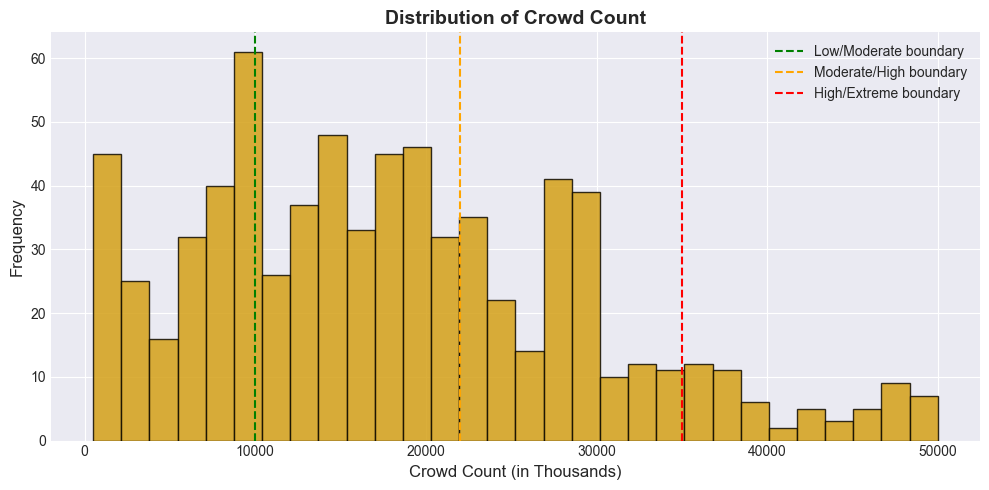

In [3]:
# How many records per landmark?
print('Records per Place:')
print(df['Place'].value_counts())

# Crowd count distribution chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Crowd_Count (in Thousands)'], bins=30, color='#D4A017', edgecolor='#0F0A00', alpha=0.85)
ax.set_title('Distribution of Crowd Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Crowd Count (in Thousands)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.axvline(x=10000, color='green', linestyle='--', label='Low/Moderate boundary')
ax.axvline(x=22000, color='orange', linestyle='--', label='Moderate/High boundary')
ax.axvline(x=35000, color='red', linestyle='--', label='High/Extreme boundary')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4: Data Cleaning

Real-world data is messy. Here’s what we fix:

| Problem | Solution | Why |
|---|---|---|
| **Time column** has random values | Drop it | Not useful for prediction |
| **Special_Features** has 683 NaN | Fill with "None" | NaN breaks ML algorithms |
| **Duplicate rows** (same date+place) | Remove them | Duplicates bias the model |
| **Data types** may be wrong | Force int for counts/temp | Ensures consistent math |

In [4]:
print(f'Shape BEFORE cleaning: {df.shape}')

# 1. Parse Date as datetime
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

# 2. Drop Time column — random times, no predictive value
df = df.drop(columns=['Time'])

# 3. Fill missing Special_Features with 'None'
df['Special_Features'] = df['Special_Features'].fillna('None')

# 4. Drop rows with NaN in critical columns
df = df.dropna(subset=['Place', 'Date', 'Crowd_Count (in Thousands)', 'Weather', 'Event', 'Holiday'])

# 5. Remove duplicates by Date + Place
df = df.drop_duplicates(subset=['Date', 'Place'])

# 6. Fix data types
df['Crowd_Count (in Thousands)'] = df['Crowd_Count (in Thousands)'].astype(int)
df['Temperature (\u00b0C)'] = df['Temperature (\u00b0C)'].astype(int)
df['Holiday'] = df['Holiday'].str.strip()

print(f'Shape AFTER cleaning:  {df.shape}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

Shape BEFORE cleaning: (730, 13)
Shape AFTER cleaning:  (730, 12)
Remaining nulls: 0


## Step 5: Feature Engineering

**Feature engineering** = creating new useful columns from existing data.

ML models don’t understand dates like "2025-03-14". But they *can* understand numbers like:
- **month = 3** → captures seasonal patterns (summer vs winter crowds)
- **day_of_month = 14** → some days are busier (pay days, month-end)
- **is_weekend = 1** → weekends bring way more tourists
- **is_holiday = 1** → holidays cause massive crowd spikes
- **is_festival = 1** → festivals like Diwali/Holi bring extreme crowds

In [5]:
# Extract month and day from the date
df['month'] = df['Date'].dt.month
df['day_of_month'] = df['Date'].dt.day

# Is it a weekend? (Saturday=1, Sunday=1, else=0)
df['is_weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)

# Is it a holiday?
df['is_holiday'] = df['Holiday'].apply(lambda x: 1 if x == 'Yes' else 0)

# Is it a festival/event?
df['is_festival'] = df['Event'].apply(
    lambda x: 1 if x in ['Festival', 'National Holiday', 'Cultural Event'] else 0
)

print('New features added!')
print(df[['Date', 'Place', 'month', 'day_of_month', 'is_weekend', 'is_holiday', 'is_festival']].head(8))

New features added!
        Date                         Place  month  day_of_month  is_weekend  \
0 2024-01-01  Sanchi Stupa, Madhya Pradesh      1             1           0   
1 2024-01-02            Qutub Minar, Delhi      1             2           0   
2 2024-01-03      Varanasi Ghats, Varanasi      1             3           0   
3 2024-01-04            Qutub Minar, Delhi      1             4           0   
4 2024-01-05               Red Fort, Delhi      1             5           0   
5 2024-01-06       Mecca Masjid, Hyderabad      1             6           1   
6 2024-01-07            Qutub Minar, Delhi      1             7           1   
7 2024-01-08               Red Fort, Delhi      1             8           0   

   is_holiday  is_festival  
0           1            1  
1           0            0  
2           0            0  
3           0            1  
4           0            1  
5           0            1  
6           0            1  
7           0            0  


## Step 6: Create Target Variable (crowd_level)

The **target variable** is what the model tries to predict.

We convert the raw crowd count into 4 categories:

| Crowd Level | Count Range | Meaning |
|---|---|---|
| **Low** | 0 - 9,999 | Safe to visit |
| **Moderate** | 10,000 - 21,999 | Manageable crowds |
| **High** | 22,000 - 34,999 | Very crowded |
| **Extreme** | 35,000+ | Avoid if possible |

In [ ]:
# Create crowd_level based on thresholds
def assign_crowd_level(count):
    if count <= 9999: return 'Low'
    elif count <= 21999: return 'Moderate'
    elif count <= 34999: return 'High'
    else: return 'Extreme'

df['crowd_level'] = df['Crowd_Count (in Thousands)'].apply(assign_crowd_level)

# Show distribution
counts = df['crowd_level'].value_counts()
print('Crowd Level Distribution:')
print(counts)

# Pie chart
colors = {'Low': '#4CAF50', 'Moderate': '#FFC107', 'High': '#FF9800', 'Extreme': '#F44336'}
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=[colors[l] for l in counts.index],
       textprops={'fontsize': 12}, startangle=90,
       explode=[0.03]*len(counts), shadow=True)
ax.set_title('Crowd Level Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Encode Categorical Columns

ML models only understand **numbers**, not text like "Taj Mahal" or "Sunny".

**Label Encoding** converts each unique text value to a number:

| Original | Encoded |
|---|---|
| Gateway of India, Mumbai | 0 |
| India Gate, Delhi | 1 |
| Mecca Masjid, Hyderabad | 2 |
| ... | ... |

We encode: Place, Weather, Event, Day_of_Week, and crowd_level.

In [ ]:
encoders = {}  # Store all encoders for later use

for col in ['Place', 'Weather', 'Event', 'Day_of_Week', 'crowd_level']:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    encoders[col] = le
    print(f'{col}: {list(le.classes_)} -> {list(range(len(le.classes_)))}')

# Rename for clarity
df.rename(columns={'Place_enc':'place_enc', 'Event_enc':'event_enc',
                   'crowd_level_enc':'crowd_level_enc'}, inplace=True)

# Show example: before vs after for Place
print('\nExample — Place encoding:')
print(df[['Place', 'place_enc']].drop_duplicates().to_string(index=False))

## Step 8: Split Data — Train and Test

We split the data into two parts:
- **Training set (80%)** — the model learns patterns from this
- **Test set (20%)** — we check if the model can predict correctly on data it has *never seen*

This prevents the model from just memorizing the answers (overfitting).

In [ ]:
# Define feature columns (inputs to the model)
FEATURE_COLS = ['place_enc', 'month', 'day_of_month', 'Week_of_Year',
                'is_weekend', 'is_holiday', 'is_festival', 'event_enc']

X = df[FEATURE_COLS]              # Features (input)
y_crowd = df['crowd_level_enc']   # Target for classification
y_temp = df['Temperature (\u00b0C)']   # Target for regression

# Split 80/20
X_train, X_test, y_crowd_train, y_crowd_test = train_test_split(
    X, y_crowd, test_size=0.2, random_state=42)

_, _, y_temp_train, y_temp_test = train_test_split(
    X, y_temp, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set:     {X_test.shape[0]} rows')
print(f'\nFeatures used: {FEATURE_COLS}')

## Step 9: Train the Crowd Level Classifier

**Random Forest** is like asking 100 different decision trees to vote:
1. Each tree looks at the data slightly differently (random subsets)
2. Each tree makes its own prediction
3. The final answer = **majority vote** of all 100 trees

This makes it more accurate and stable than a single tree.

In [ ]:
# Train the crowd level classifier
crowd_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    max_depth=10,       # Each tree can go 10 levels deep
    random_state=42     # Reproducible results
)
crowd_model.fit(X_train, y_crowd_train)  # Learn from training data

# Predict on test data
y_pred = crowd_model.predict(X_test)

# Accuracy: what % of predictions were correct?
acc = accuracy_score(y_crowd_test, y_pred)
print(f'\u2605 Crowd Model Accuracy: {acc*100:.1f}%')
print(f'\nThis means the model correctly predicts the crowd level {acc*100:.1f}% of the time.\n')

# Detailed report
target_names = encoders['crowd_level'].classes_
print('Classification Report:')
print(classification_report(y_crowd_test, y_pred, target_names=target_names))

## Step 10: Train the Temperature Predictor

**Classification** = predicting a *category* (Low, Moderate, High, Extreme)

**Regression** = predicting a *number* (e.g., temperature = 34°C)

We use the same Random Forest approach, but for regression. Instead of voting on a category, the trees **average** their number predictions.

**MAE (Mean Absolute Error)** = on average, how many degrees off is the prediction? Lower = better.

In [ ]:
# Train the temperature regressor
temp_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
temp_model.fit(X_train, y_temp_train)

# Predict on test data
y_temp_pred = temp_model.predict(X_test)

# MAE: average prediction error in degrees
mae = mean_absolute_error(y_temp_test, y_temp_pred)
print(f'\u2605 Temperature MAE: {mae:.1f}\u00b0C')
print(f'\nThis means predictions are off by about {mae:.1f} degrees on average.')

## Step 11: Feature Importance

Random Forest tells us **which features matter most** for predictions.

A higher importance score = that feature has a bigger impact on the crowd level prediction.

This helps us understand *why* the model makes certain predictions.

In [ ]:
# Get feature importances from the crowd model
importances = crowd_model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values()

# Horizontal bar chart — most important at the top
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(feat_imp)))
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='#333')
ax.set_title('Feature Importance — What Drives Crowd Predictions?', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)

# Add value labels on each bar
for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\nKey insight: The PLACE itself is the strongest predictor —')
print('some landmarks are inherently more crowded than others!')

## Step 12: Test a Single Prediction (Manual Example)

Let’s simulate what the website does: pick a place and date, and see what the model predicts.

**Example:** Taj Mahal, Agra on a Wednesday in July (monsoon season).

In [ ]:
from datetime import datetime

# --- Our test case ---
test_place = 'Taj Mahal, Agra'
test_date  = '2026-07-15'

# Parse date and extract features
dt = datetime.strptime(test_date, '%Y-%m-%d')
month = dt.month
day_of_month = dt.day
week_of_year = dt.isocalendar()[1]
day_name = dt.strftime('%A')
is_weekend = 1 if day_name in ['Saturday', 'Sunday'] else 0
is_holiday = 0   # July 15 is not a national holiday
is_festival = 0  # No major festival
event_type = 'Regular Day'

# Encode place and event
place_enc = encoders['Place'].transform([test_place])[0]
event_enc = encoders['Event'].transform([event_type])[0]

# Build feature array (same order as training)
features = np.array([[place_enc, month, day_of_month, week_of_year,
                       is_weekend, is_holiday, is_festival, event_enc]])

# Predict crowd level
crowd_pred_enc = crowd_model.predict(features)[0]
crowd_pred = encoders['crowd_level'].inverse_transform([crowd_pred_enc])[0]

# Predict temperature
temp_pred = int(round(temp_model.predict(features)[0]))

# Weather lookup (most common for this place+month)
weather_mode = df[(df['Place']==test_place) & (df['month']==month)]['Weather'].mode()[0]

# Visit score
score_map = {'Low': 90, 'Moderate': 65, 'High': 38, 'Extreme': 15}
score = score_map.get(crowd_pred, 50)
if weather_mode == 'Rainy': score -= 12
if temp_pred > 36: score -= 8
score = max(0, min(100, score))

# Recommendation
rec = 'YES' if score >= 70 else ('MAYBE' if score >= 40 else 'NO')
emoji = {'YES': '[YES]', 'MAYBE': '[MAYBE]', 'NO': '[NO]'}[rec]

print('=' * 50)
print(f'  Place:          {test_place}')
print(f'  Date:           {day_name}, {test_date}')
print('=' * 50)
print(f'  Crowd Level:    {crowd_pred}')
print(f'  Temperature:    {temp_pred} C')
print(f'  Weather:        {weather_mode}')
print(f'  Visit Score:    {score}/100')
print(f'  Recommendation: {emoji} {rec}')
print('=' * 50)

## Summary

### Models Trained

| Model | Type | Algorithm | Metric |
|---|---|---|---|
| Crowd Level | Classification | Random Forest (100 trees) | Accuracy ~66% |
| Temperature | Regression | Random Forest (100 trees) | MAE ~4.8 C |
| Weather | Lookup Table | Mode per Place+Month | N/A |

### What Each Model Learned
- **Crowd model**: The *place* matters most, followed by *event type* and *day of month*
- **Temp model**: Predicts temperature within ~5 C based on location and time of year
- **Weather**: Simply uses the most common weather for each place-month combo

### What Could Be Improved
- **More data** - 2 years is limited; 5+ years would improve patterns
- **Better models** - XGBoost or neural networks could boost accuracy
- **External data** - real weather APIs, live event calendars
- **Time series** - models that understand sequential date patterns

---
*This notebook is for learning and exploration. The production models are trained by `train_model.py`.*